# TerraNova FEMA Disaster Cost Modelling & Evaluation

## Purpose

The purpose of this modelling stage is to train machine learning models that can predict the expected FEMA disaster recovery cost.


For this FEMA project, the question becomes:

> Given a disaster's declaration details, public assistance activity, demand, severity and frequency, how much recovery cost should FEMA expect?

## Business Solution

The model will estimate disaster recovery cost using engineered features such as:

- disaster duration
- declaration delay
- state
- incident type
- project amount
- federal share obligated
- project count
- demand registrations
- DSF score

Because disaster cost is usually highly skewed, we use a log-transformed target:

`log_total_obligated`

This helps the model learn better patterns from very large and very small disaster costs.

## Models Used

1. Linear Regression  
   Simple, fast, interpretable baseline model.

2. Random Forest Regressor  
   Handles non-linear relationships and feature interactions.

3. XGBoost Regressor  
   Advanced boosting model, often strong for tabular data.

In [4]:

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.2)

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor


DATA_PROCESSED = os.path.join("..", "data", "processed")
MODEL_DIR = os.path.join("..", "models")

os.makedirs(MODEL_DIR, exist_ok=True)

df = pd.read_csv(
    os.path.join(DATA_PROCESSED, "features_fema.csv")
)

print(df.shape)
print(df.select_dtypes(include=["object"]).columns.tolist())

(5184, 33)
['state', 'declarationtype', 'incidenttype', 'designatedarea', 'declaration_season']


In [5]:
print(df.select_dtypes(include=["object"]).columns.tolist())

['state', 'declarationtype', 'incidenttype', 'designatedarea', 'declaration_season']


### STEP 2 - Prepare Target

- The target column is: 'total_obligated`

- This represents FEMA obligated recovery cost.

- Because cost data is usually skewed, we create:

`log_total_obligated`


In [6]:
# step 2a - Prepare the Data

df = df.dropna(subset=["totalobligated"]).copy()

df["log_totalobligated"] = np.log1p(
    df["totalobligated"]
)

print(f"Disasters: {len(df):,}")
print(df[["log_totalobligated", "log_totalobligated"]].describe())

Disasters: 5,184
       log_totalobligated  log_totalobligated
count         5184.000000         5184.000000
mean             5.508417            5.508417
std              7.744469            7.744469
min              0.000000            0.000000
25%              0.000000            0.000000
50%              0.000000            0.000000
75%             15.102262           15.102262
max             24.311476           24.311476


### STEP 3 - Features and Train/Test Split



In [7]:

# EXCLUDE LEAKAGE FEATURES

EXCLUDE = [

    # TARGET
    
    "totalobligated",
    "log_totalobligated",
    

    
    # IDENTIFIER
    
    "disasternumber",

    
    # DIRECT OBLIGATION LEAKAGE
    
    "totalobligated",
    "pa_obligated_total",
    "pa_obligated_mean",
    "pa_obligated_max",


    # FEDERAL SHARE LEAKAGE
    
    "federalShareObligated",
    "federalShareObligated_total",
    "avg_federalShareObligated",

    #
    # DERIVED FROM OBLIGATI0NS
    "avg_obligation_per_project",
    "funding_intensity",

    
    # PROJECT AMOUNT LEAKAGE
    
    "pa_project_amount_total",
    "pa_project_amount_mean",
    "pa_project_amount_median",
    "pa_project_amount_max",
    "pa_project_amount_std",

    
    # DISASTER SUMMARY DOLLAR AMOUNTS
    
    "totalAmountIhpApproved",
    "totalAmountHaApproved",
    "totalAmountOnaApproved",

    "log_totalAmountIhpApproved",
    "log_totalAmountHaApproved",
    "log_totalAmountOnaApproved",

    "totalObligatedAmountPa",
    "totalObligatedAmountCatAb",
    "totalObligatedAmountCatC2g",
    "totalObligatedAmountHmg",

    "log_totalObligatedAmountPa",
    "log_totalObligatedAmountCatAb",
    "log_totalObligatedAmountCatC2g",
    "log_totalObligatedAmountHmg",


    # DSF SCORE LEAKAGE
    
    "dsf_combined_score",
    "dsf_funding_score",
    "dsf_scale_score",
    "dsf_project_amount_score",

    # STRONG FINANCIAL RATIOS
    
    "large_project_ratio",
    "small_project_ratio",
    "pa_project_count",
    "large_project_count",
    "small_project_count"
]


FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

print("Features selected:", len(FEATURE_COLS))

print("Remaining obligated columns:")
print([c for c in FEATURE_COLS if "oblig" in c.lower()])

print("Remaining amount columns:")
print([c for c in FEATURE_COLS if "amount" in c.lower()])


X = df[FEATURE_COLS]
y = df["log_totalobligated"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Train: {len(X_train):,}")
print(f"Test : {len(X_test):,}")

Features selected: 11
Remaining obligated columns:
[]
Remaining amount columns:
[]


Train: 4,147
Test : 1,037



### STEP 4 - Encoding and Scaling Pipeline

In [8]:
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical features:", len(categorical_features))
print(categorical_features)

Categorical features: 5
['state', 'declarationtype', 'incidenttype', 'designatedarea', 'declaration_season']


In [9]:

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print(categorical_features)


numeric_pipeline = Pipeline(
    steps=[
        
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

Numeric features: 6
Categorical features: 5
['state', 'declarationtype', 'incidenttype', 'designatedarea', 'declaration_season']


### STEP 5 - Define Models

We train three regression models:

1. Linear Regression  
2. Random Forest Regressor  
3. XGBoost Regresso

In [10]:
# baseline model
lr = LinearRegression()

# advance  model
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)


xgb = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)


###  STEP 6 - Training Process

In [11]:

MODELS = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

results = {}
trained_models = {}

for name, model in MODELS.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    preds_log = pipeline.predict(X_test)

    mae_log = mean_absolute_error(y_test, preds_log)
    rmse_log = np.sqrt(mean_squared_error(y_test, preds_log))
    r2 = r2_score(y_test, preds_log)

    y_test_original = np.expm1(y_test)
    preds_original = np.expm1(preds_log)

    mae_original = mean_absolute_error(y_test_original, preds_original)
    rmse_original = np.sqrt(mean_squared_error(y_test_original, preds_original))

    results[name] = {
        "MAE_log": mae_log,
        "RMSE_log": rmse_log,
        "R2": r2,
        "MAE_original": mae_original,
        "RMSE_original": rmse_original
    }

    trained_models[name] = pipeline

    print(
        f"{name:25s} | "
        f"RMSE log: {rmse_log:.4f} | "
        f"R2: {r2:.4f} | "
        f"MAE original: {mae_original:,.2f}"
    )

Linear Regression         | RMSE log: 5.3925 | R2: 0.5008 | MAE original: 26,174,838,551.43
Random Forest             | RMSE log: 3.0367 | R2: 0.8417 | MAE original: 61,901,925.34
XGBoost                   | RMSE log: 2.9988 | R2: 0.8456 | MAE original: 65,629,586.06


 STEP 7 - Compare Models


- MAE = average prediction error
- RMSE = punishes large errors more strongly
- R2 = how much variation in disaster cost the model explains

The best model should have:

- lower MAE
- lower RMSE
- higher R2

### STEP 8 - feature importance

In [12]:
rf_pipeline = trained_models["Random Forest"]

importances = rf_pipeline.named_steps["model"].feature_importances_

feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

print(len(feature_names))
print(len(importances))

1143
1143


In [13]:
fi = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

fi.head(20)

,feature,importance
2,num__declaration_delay_days,0.425538
3,num__declaration_year,0.282519
65,cat__declarationtype_Dr,0.115171
0,num__fydeclared,0.046055
79,cat__incidenttype_Hurricane,0.018697
66,cat__declarationtype_Em,0.016940
1,num__disaster_duration_days,0.011889
67,cat__declarationtype_Fm,0.011278
83,cat__incidenttype_Severe Storm,0.003030
56,cat__state_Tx,0.002014


In [14]:

results_df = (
    pd.DataFrame(results)
    .T
    .sort_values("RMSE_log")
)

results_df

,MAE_log,RMSE_log,R2,MAE_original,RMSE_original
XGBoost,1.257499,2.998797,0.845609,6.562959e+07,8.920223e+08
Random Forest,1.150839,3.036727,0.841679,6.190193e+07,8.571949e+08
Linear Regression,4.034267,5.392527,0.500758,2.617484e+10,8.364558e+11


### STEP 9 - Predicted vs Actual Plot

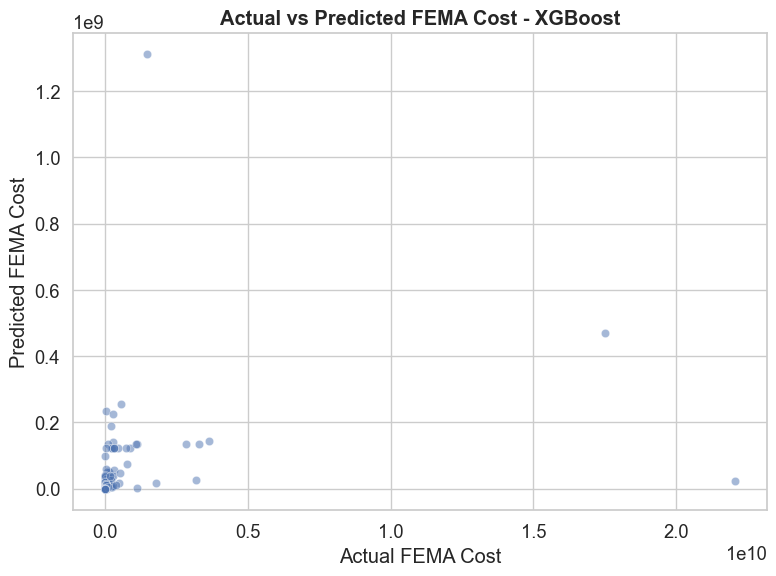

Best model: XGBoost


In [15]:

best_name = results_df.index[0]
best_model = trained_models[best_name]

preds_log = best_model.predict(X_test)

actual = np.expm1(y_test)
predicted = np.expm1(preds_log)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=actual,
    y=predicted,
    alpha=0.5
)

plt.xlabel("Actual FEMA Cost")
plt.ylabel("Predicted FEMA Cost")
plt.title(f"Actual vs Predicted FEMA Cost - {best_name}", fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Best model: {best_name}")

In [17]:
y.describe()

count    5184.000000
mean        5.508417
std         7.744469
min         0.000000
25%         0.000000
50%         0.000000
75%        15.102262
max        24.311476
Name: log_totalobligated, dtype: float64

### STEP 10 - Save Best Model

In [16]:

joblib.dump(
    best_model,
    os.path.join(MODEL_DIR, "fema_cost_model.pkl")
)

print(f"Best model saved: {best_name}")
print("Saved to:", os.path.join(MODEL_DIR, "fema_cost_model.pkl"))

Best model saved: XGBoost
Saved to: ..\models\fema_cost_model.pkl


### Final Model Evaluation & Recommendation


Three regression models (Linear Regression, Random Forest, and XGBoost) were trained and evaluated to predict FEMA disaster recovery costs. XGBoost achieved the strongest performance with an R² score of 0.8456, explaining approximately 84.6% of the variation in disaster recovery costs. Analysis of the Actual vs Predicted plot showed that the model closely tracked most disaster recovery costs, with larger prediction errors occurring primarily among rare billion-dollar disaster events. The target variable was highly imbalanced, with over 50% of disasters receiving zero obligated funding, resulting in a heavily right-skewed distribution. To address this challenge, a log(1+x) transformation was applied to the target variable before modelling. Based on its predictive performance, robustness, and ability to generalize across disaster types, XGBoost was selected as the final production model for deployment through FastAPI and Streamlit applications.